# Reduce perceived latency by using state streaming

In [1]:
from dotenv import load_dotenv
load_dotenv("../../.env")


from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

from IPython.display import Image, display

from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, HumanMessage, convert_to_openai_messages

#qdrant
from qdrant_client.http.models import MatchValue, FieldCondition, Filter, MatchAny, FusionQuery
from qdrant_client.models import VectorParams, Distance, SparseVectorParams, Modifier, PayloadSchemaType, PointStruct, Document, Prefetch, RrfQuery, Rrf 
from qdrant_client import QdrantClient

import openai

from langsmith import traceable, get_current_run_tree
import instructor
from pydantic import BaseModel, Field

from jinja2 import Template

from typing import Annotated, List, Any
from operator import add

from sentence_transformers import CrossEncoder

# persistence in multi turn conversations
from langgraph.checkpoint.postgres import PostgresSaver
import os

/Users/dom/Documents/GitHub/e2e-engineering-course/E2E-AI-Engineering-Bootcamp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "text-embedding-3-small"
    }
)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    current_run = get_current_run_tree()
    if current_run:
        current_run.metadata["usage_metadata"] = {
            "input_tokens": response.usage.prompt_tokens,
            "total_tokens": response.usage.total_tokens,
        }

    return response.data[0].embedding

### Product Retrieval with hybrid search

In [3]:
model = None

def get_or_load_reranker() -> CrossEncoder:
    global model
    
    if model is not None:
        return model
    else:
        # detect ideal accelerator, if available
        import torch as T
        def get_device():
            if T.cuda.is_available():
                return "cuda"
            elif hasattr(T.backends, "mps") and T.backends.mps.is_available():
                # Check if MPS is built and available on Mac
                return "mps"
            return "cpu"

        model = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2', device=get_device())
        return model


# immediately preload the reranker
get_or_load_reranker()

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 7608.75it/s]


CrossEncoder(
  (0): Transformer({'transformer_task': 'sequence-classification', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'logits'}}, 'module_output_name': 'scores', 'architecture': 'BertForSequenceClassification'})
)

In [4]:
def rerank_data(query, results, only_k: int = None, additional_lists_to_sort: list[list] = None):
    model = get_or_load_reranker()
    
    rerank_scores = model.rank(query, results)

    reranked_results = []
    if additional_lists_to_sort is not None:
        reranked_additional_lists_to_sort = [[] for _ in range(len(additional_lists_to_sort))]

    for rerank in rerank_scores:
        reranked_idx = rerank["corpus_id"]
        # guard positions that are not in the k items we want
        if only_k is not None and reranked_idx > only_k:
            continue

        reranked_results.append(results[reranked_idx])

        # if given also rerank the other lists to sort
        if additional_lists_to_sort is not None:
            for li_id, li in enumerate(additional_lists_to_sort):
                reranked_additional_lists_to_sort[li_id].append(li[reranked_idx])

    return reranked_results, *reranked_additional_lists_to_sort

In [5]:
@tool
@traceable(
    name="retrieve_products",
    run_type="embedding",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "text-embedding-3-small"
    }
)
def retrieve_formatted_products(query: str, k: int = 10) -> str:
    """Retrieves information about available products as a formatted string with each products id, rating and description on a single line starting with a "-".
    The search is performed using BM25 and cosine similarity with RRF and reranking afterwards to retrieve the k items.

    Arg:
        query: The search string that is used to perform search for products
        k: Top k items that will be returned by the tool

    Returns:
        A formatted string that contains the k products that best fit the searched query
    """
    query_embedding = get_embedding(query)
    
    qdrant_client = QdrantClient(url="http://localhost:6333")

    #hybrid retrieval
    results = qdrant_client.query_points(
        collection_name="Amazon-items-collection-hybrid-search",
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="text-embedding-3-small",
                limit=k
            ),
            Prefetch(
                query=Document(
                    text=query,
                    model="qdrant/bm25"
                ),
                using="bm25",
                limit=k
            )
        ],
        query=RrfQuery(rrf=Rrf(weights=[0.4, 0.6])),
        limit=2*k
    )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])
    
    # reranking
    reranked_retrieved_context, reranked_context_ids, reranked_context_ratings = rerank_data(
        query, 
        retrieved_context, 
        only_k=k, 
        additional_lists_to_sort=[retrieved_context_ids, retrieved_context_ratings])

    # formatting the retrieved & reranked context
    formatted_context = ""

    for id, chunk, rating in zip(reranked_context_ids, reranked_retrieved_context, reranked_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return formatted_context
    
    # return {
    #     "retrieved_context_ids": retrieved_context_ids,
    #     "retrieved_context": retrieved_context,
    #     "similarity_scores": similarity_scores,
    #     "retrieved_context_ratings": retrieved_context_ratings
    # }

### Retrieval of Reviews data

In [6]:
### Reviews tool ###
@tool
@traceable(
    name="retrieve_prefiltered_reviews",
    run_type="embedding",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "text-embedding-3-small"
    }
)
def retrieve_prefiltered_reviews(query: str, parent_asins: list[str], k: int = 10) -> str:
    """Retrieves reviews for a list of parent ASINs as a formatted string with each review on a single line starting with a "-".
    The search is performed using BM25 and cosine similarity with RRF and reranking afterwards to retrieve the k items.

    Args:
        query: The search string that is used to perform search for reviews
        parent_asins: The list of parent ASINs to filter the reviews by
        k: The number of reviews to retrieve

    Returns:
        A formatted string that contains the k reviews that best fit the searched query
    """
    query_embedding = get_embedding(query)

    qdrant_client = QdrantClient(url="http://localhost:6333")

    #hybrid retrieval
    results = qdrant_client.query_points(
        collection_name="Amazon-reviews-collection-hybrid-search",
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="text-embedding-3-small",
                filter=Filter(
                    must=[
                        FieldCondition(
                            key="parent_asin", 
                            match=MatchAny(
                                any=parent_asins
                            )
                        )
                    ]
                ),
                limit=20
            ),
        ],
        query=FusionQuery(fusion="rrf"),
        limit=k
    )


    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_content"])
        similarity_scores.append(result.score)
    

    formatted_context = ""

    for id, review in zip(retrieved_context_ids, retrieved_context):
        formatted_context += f"- ID: {id}, User Review: {review}\n"

    return formatted_context

### Structured Outputs of the Agent

In [7]:
class RagUsedContext(BaseModel):
    id: str = Field(description="ID of the item used to answer the question")
    description: str = Field(description="Description of the item used to answer the question")

class FinalResponse(BaseModel):
    answer: str = Field(description="Final answer to the question")
    citations: list[RagUsedContext] = Field(description="List of items that were relevant to create the final answer")

class State(BaseModel):
    messages: Annotated[List[Any], add] = []
    iteration: int = 0
    answer: str = ""
    final_answer: bool = False
    question_relevant: bool = False

### Agent Node

In [8]:
from langchain_core.messages import AIMessage
@traceable(
    name="rag_agent_node",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def agent_node(state: State) -> dict:
    jinja_prompt_template = """# Role: 
    - You are a shopping assistant that answers customer questions about the available products on our marketplace.

    # Goal: 
    - Give the customer a direct and polite answer to their question given the output of available tools. If the tools did not yield any relevant information mention that you are not able to find information on it, if there is no information in the context.

    # Instructions:
    - Use available tools to answer product related questions
    - Never fabricate information about products that are not mentioned in the context or through tool calls
    - When discribing products use relevant details
    - If there are no products returned by any tools, ask the customer to rephrase their request and you were not able to find anything related to this request
    - If the customer doesn't state anything related to products in their request ask them to specify which product they are interested in
    - Refer to data in context always as "available products" and never as "context"
    - Try answering queries that are not previse by broadening the search radius i.e. product categories instead of specific brand
    """
    template = Template(jinja_prompt_template)

    prompt = template.render()

    llm_client = ChatOpenAI(
        model="gpt-5.4-mini",
        reasoning_effort="none",
        use_responses_api=True
    )

    llm_client_with_tools = llm_client.bind_tools(
        [retrieve_formatted_products, retrieve_prefiltered_reviews, FinalResponse],
        tool_choice="auto"
    )

    response = llm_client_with_tools.invoke([
        SystemMessage(content=prompt),
        *state.messages
    ])

    final_answer = False
    answer = ""
    citations = []


    def sanitise_repsonse(response):
        for tool_call in response.tool_calls:
            if tool_call.get("name") == "FinalResponse":
                answer = tool_call.get("args").get("answer")
                break
                # removing any toolcall suggestions by doing so
        return AIMessage(content=answer)

    if len(response.tool_calls) > 0:
        for tool_call in response.tool_calls:
            if tool_call.get("name") == "FinalResponse":
                final_answer = True
                answer = tool_call.get("args").get("answer")
                citations.extend(tool_call.get("args").get("citations"))

                response = sanitise_repsonse(response)
                break

    return {
        "messages": [response],
        "final_answer": final_answer,
        "answer": answer,
        "citations": citations,
        "iteration": state.iteration + 1
    }


In [21]:
def tool_router_conditional_edges(state: State) -> dict:
    if state.final_answer:
        return "end"
    elif state.iteration >= 3:
        return "end"
    elif len(state.messages[-1].tool_calls) > 0:
        return "tools"
    else:
        return "end"

In [22]:
workflow = StateGraph(State)

tools = [retrieve_formatted_products, retrieve_prefiltered_reviews]
tool_node = ToolNode(tools)

# nodes
workflow.add_node("agent_node", agent_node)
workflow.add_node("tool_node", tool_node)


# edges
workflow.add_edge(START, "agent_node")
workflow.add_conditional_edges(
    "agent_node",
    tool_router_conditional_edges,
    {
        "tools": "tool_node",
        "end": END
    }
)
workflow.add_edge("tool_node", "agent_node")
workflow.add_edge("agent_node", END)

graph = workflow.compile()


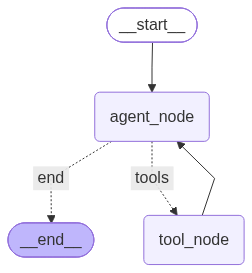

In [23]:
display(Image(
    graph.get_graph().draw_mermaid_png()
))

In [24]:
initial_state = {
    "messages": [HumanMessage(content="Can I get a tablet for my kid, a watch for my wife and a waterproof speaker for my pool party?")],
}

### Persistent State

In [25]:
# setup postgres DB
db = os.environ["MULTI_TURN_POSTGRES_DB"]
user = os.environ["MULTI_TURN_POSTGRES_USER"]
password = os.environ["MULTI_TURN_POSTGRES_PASSWORD"]
HOST = "localhost"
PORT = "5432"

with PostgresSaver.from_conn_string(
    f"postgresql://{user}:{password}@{HOST}:{PORT}/{db}"
    ) as checkpointer:
    checkpointer.setup()

### Multiturn Conversation

#### Stream Mode: Updates

In [26]:
initial_state = {
    "messages": [HumanMessage(content="Can I get a tablet for my kid, a watch for my wife and a waterproof speaker for my pool party?")],
}

config = {
    "configurable": {
        "thread_id": "00000000004"
    }
}

with PostgresSaver.from_conn_string(
    f"postgresql://{user}:{password}@{HOST}:{PORT}/{db}"
    ) as checkpointer:
    graph = workflow.compile(checkpointer=checkpointer)

    for chunk in graph.stream( #dont invoke but rather stream the events from the graph
        initial_state,
        config=config,
        stream_mode=["updates"]
    ):
        print(chunk)


('updates', {'agent_node': {'messages': [AIMessage(content=[{'arguments': '{"query":"tablet for kids child tablet family educational tablet","k":5}', 'call_id': 'call_y6qJEJ3eDuE4hewUEpklVegL', 'name': 'retrieve_formatted_products', 'type': 'function_call', 'id': 'fc_00a326a3c597ef43006a6510df473881a3b3d36bcadd4213b1', 'status': 'completed'}, {'arguments': '{"query":"women\'s watch watch for wife smartwatch elegant watch","k":5}', 'call_id': 'call_dViCwIs2nmKyQD3p8ogi3RwD', 'name': 'retrieve_formatted_products', 'type': 'function_call', 'id': 'fc_00a326a3c597ef43006a6510df474c81a39f025d1a64b8cc64', 'status': 'completed'}, {'arguments': '{"query":"waterproof speaker pool party bluetooth speaker outdoor waterproof","k":5}', 'call_id': 'call_41ZdJcZxyWblTxGVArMkrc41', 'name': 'retrieve_formatted_products', 'type': 'function_call', 'id': 'fc_00a326a3c597ef43006a6510df475481a3a8aadd739e5fb322', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_00a326a3c597ef43006

#### Stream mode: debug

In [28]:
initial_state = {
    "messages": [HumanMessage(content="Can I get a tablet for my kid, a watch for my wife and a waterproof speaker for my pool party?")],
}

config = {
    "configurable": {
        "thread_id": "000000000010"
    }
}

with PostgresSaver.from_conn_string(
    f"postgresql://{user}:{password}@{HOST}:{PORT}/{db}"
    ) as checkpointer:
    graph = workflow.compile(checkpointer=checkpointer)

    for chunk in graph.stream( #dont invoke but rather stream the events from the graph
        initial_state,
        config=config,
        stream_mode=["debug"]
    ):
        print(chunk)


('debug', {'step': -1, 'timestamp': '2026-07-25T19:45:17.267810+00:00', 'type': 'checkpoint', 'payload': {'config': {'configurable': {'checkpoint_ns': '', 'thread_id': '000000000010', 'checkpoint_id': '1f188615-ca38-6048-bfff-0fcba1c133c1'}}, 'parent_config': None, 'values': {'messages': []}, 'metadata': {'source': 'input', 'step': -1, 'parents': {}}, 'next': ['__start__'], 'tasks': [{'id': 'f2f53d54-3ec1-d4ab-df51-66c63d6ba1f7', 'name': '__start__', 'interrupts': (), 'state': None}]}})
('debug', {'step': 0, 'timestamp': '2026-07-25T19:45:17.275127+00:00', 'type': 'checkpoint', 'payload': {'config': {'configurable': {'checkpoint_ns': '', 'thread_id': '000000000010', 'checkpoint_id': '1f188615-ca4f-6702-8000-0a7114bcffab'}}, 'parent_config': {'configurable': {'checkpoint_ns': '', 'thread_id': '000000000010', 'checkpoint_id': '1f188615-ca38-6048-bfff-0fcba1c133c1'}}, 'values': {'messages': [HumanMessage(content='Can I get a tablet for my kid, a watch for my wife and a waterproof speaker 

In [30]:
initial_state = {
    "messages": [HumanMessage(content="Can I get a tablet for my kid, a watch for my wife and a waterproof speaker for my pool party?")],
}

config = {
    "configurable": {
        "thread_id": "000000000012"
    }
}

chunks = []

with PostgresSaver.from_conn_string(
    f"postgresql://{user}:{password}@{HOST}:{PORT}/{db}"
    ) as checkpointer:
    graph = workflow.compile(checkpointer=checkpointer)

    for chunk in graph.stream( #dont invoke but rather stream the events from the graph
        initial_state,
        config=config,
        stream_mode=["updates", "tasks"]
    ):
       print(chunk)
       chunks.append(chunk)


('tasks', {'id': 'b74f8925-1463-ae1d-9e27-5c62ec5b71ad', 'name': 'agent_node', 'input': State(messages=[HumanMessage(content='Can I get a tablet for my kid, a watch for my wife and a waterproof speaker for my pool party?', additional_kwargs={}, response_metadata={})], iteration=0, answer='', final_answer=False, question_relevant=False), 'triggers': ('branch:to:agent_node',)})
('updates', {'agent_node': {'messages': [AIMessage(content=[{'arguments': '{"query":"tablet for kid child-friendly tablet parental controls durable educational tablet","k":5}', 'call_id': 'call_3P5f5VCE7l8O1nfFpkakRgcN', 'name': 'retrieve_formatted_products', 'type': 'function_call', 'id': 'fc_052a42faa1c2aca5006a65f566a2d081a394abed1d4687637b', 'status': 'completed'}, {'arguments': '{"query":"watch for wife women\'s watch smartwatch elegant gift watch","k":5}', 'call_id': 'call_l7XXFIHysthQIeZGYqsXKiAb', 'name': 'retrieve_formatted_products', 'type': 'function_call', 'id': 'fc_052a42faa1c2aca5006a65f566a2e881a39b

In [34]:
initial_state = {
    "messages": [HumanMessage(content="Can I get a tablet for my kid, a watch for my wife and a waterproof speaker for my pool party?")],
}

config = {
    "configurable": {
        "thread_id": "000000000013"
    }
}

chunks = []

with PostgresSaver.from_conn_string(
    f"postgresql://{user}:{password}@{HOST}:{PORT}/{db}"
    ) as checkpointer:
    graph = workflow.compile(checkpointer=checkpointer)

    for chunk in graph.stream( #dont invoke but rather stream the events from the graph
        initial_state,
        config=config,
        stream_mode=["updates", "debug"]
    ):
       print(chunk)
       chunks.append(chunk)


('debug', {'step': -1, 'timestamp': '2026-07-26T11:56:10.554459+00:00', 'type': 'checkpoint', 'payload': {'config': {'configurable': {'checkpoint_ns': '', 'thread_id': '000000000013', 'checkpoint_id': '1f188e8f-e4e5-62d8-bfff-3d5b85192e38'}}, 'parent_config': None, 'values': {'messages': []}, 'metadata': {'source': 'input', 'step': -1, 'parents': {}}, 'next': ['__start__'], 'tasks': [{'id': '8723b2b2-bc22-23e3-bd2a-ae340b81cb8b', 'name': '__start__', 'interrupts': (), 'state': None}]}})
('debug', {'step': 0, 'timestamp': '2026-07-26T11:56:10.555606+00:00', 'type': 'checkpoint', 'payload': {'config': {'configurable': {'checkpoint_ns': '', 'thread_id': '000000000013', 'checkpoint_id': '1f188e8f-e4ea-610c-8000-826abbc6d249'}}, 'parent_config': {'configurable': {'checkpoint_ns': '', 'thread_id': '000000000013', 'checkpoint_id': '1f188e8f-e4e5-62d8-bfff-3d5b85192e38'}}, 'values': {'messages': [HumanMessage(content='Can I get a tablet for my kid, a watch for my wife and a waterproof speaker 

### Displaying the tasks and states to the user

In [ ]:
def process_graph_events(chunk):
    """Process debug events to display user friendly state updates"""
    def _is_node_start(chunk):
        return chunk[1].get("type") == "task"
    
    def _tool_to_text(tool_call):
        if tool_call.get("name") == "retrieve_formatted_products":
            return f"Looking for items: {tool_call.get("args").get("query", "")}" 
        elif tool_call.get("name") == "retrieve_prefiltered_reviews":
            return f"Looking for user reviews..." 
        
    if _is_node_start(chunk):
        if chunk[1].get("payload", {}).get("name") == "agent_node":
            print("Planning...")
                
        elif chunk[1].get("payload", {}).get("name") == "tool_node":
            message = " ".join([_tool_to_text(tool_call) for tool_call in chunk[1].get('payload', {}).get('input', {}).messages[-1].tool_calls])
            print(message)

    
    

In [ ]:
initial_state = {
    "messages": [HumanMessage(content="Can I get a tablet for my kid, a watch for my wife and a waterproof speaker for my pool party?")],
}

config = {
    "configurable": {
        "thread_id": "000000000019"
    }
}

chunks = []

with PostgresSaver.from_conn_string(
    f"postgresql://{user}:{password}@{HOST}:{PORT}/{db}"
    ) as checkpointer:
    graph = workflow.compile(checkpointer=checkpointer)

    for chunk in graph.stream( #dont invoke but rather stream the events from the graph
        initial_state,
        config=config,
        stream_mode=["updates", "debug"]
    ):
        chunks.append(chunk)
        process_graph_events(chunk)


Planning...
Looking for items: tablet for kid child-friendly tablet durable parental controls kids tablet Looking for items: watch for woman women's watch smartwatch fashion watch gift for wife Looking for items: waterproof speaker pool party portable bluetooth speaker waterproof outdoor speaker
Planning...


In [64]:
# replay the graph manually
for chunk in chunks:
    process_graph_events(chunk)

Planning...
Looking for items: tablet for kid child-friendly tablet durable parental controls kids tablet Looking for items: watch for woman women's watch smartwatch fashion watch gift for wife Looking for items: waterproof speaker pool party portable bluetooth speaker waterproof outdoor speaker
Planning...
